In [1]:
from pymongo import MongoClient
from dotenv import load_dotenv
import pandas as pd
import os

load_dotenv(".env")

client = MongoClient(os.getenv("MONGO_URI"))
db = client[os.getenv("MONGO_DB_NAME")]
coleccion = db[os.getenv("MONGO_COLLECTION_PROCESSED")]

datos = list(
    coleccion.find(
        {},
        {
            "_id": 0,
            "precio": 1,
            "m2": 1,
            "dormitorios": 1,
            "banos": 1
        }
    )
)

df = pd.DataFrame(datos)

df = df.dropna()

df = df[
    (df["precio"] > 0) &
    (df["m2"] > 0)
]

print(df.shape)
df.head()

(1926, 4)


,banos,dormitorios,m2,precio
0,1,1,54,620000
1,2,3,80,600000
2,1,2,54,550000
3,2,2,68,630000
4,1,3,50,380000


In [2]:
from sklearn.preprocessing import StandardScaler

variables = df[["precio", "m2", "dormitorios", "banos"]]

scaler = StandardScaler()

X = scaler.fit_transform(variables)

print(X.shape)

(1926, 4)


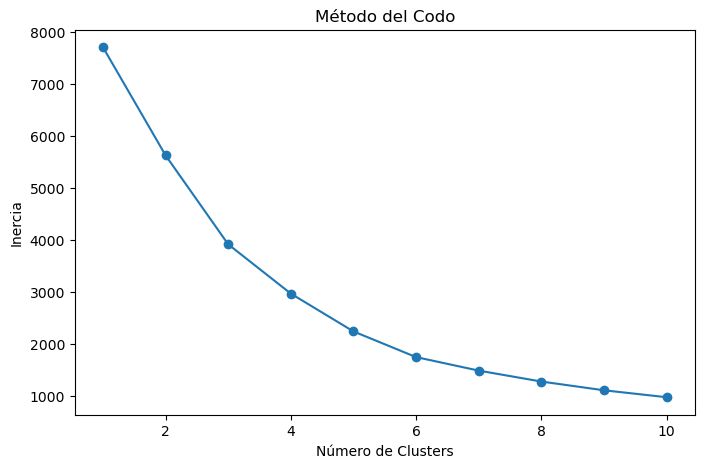

In [3]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inercias = []

for k in range(1, 11):

    modelo = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    modelo.fit(X)
    inercias.append(modelo.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), inercias, marker="o")
plt.xlabel("Número de Clusters")
plt.ylabel("Inercia")
plt.title("Método del Codo")
plt.show()

In [4]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df["cluster"] = kmeans.fit_predict(X)

df.head()

,banos,dormitorios,m2,precio,cluster
0,1,1,54,620000,0
1,2,3,80,600000,2
2,1,2,54,550000,0
3,2,2,68,630000,2
4,1,3,50,380000,0


In [5]:
df["cluster"].value_counts()

cluster
2    960
0    687
1    240
3     39
Name: count, dtype: int64

In [6]:
df.groupby("cluster")[["precio", "m2", "dormitorios", "banos"]].mean()

,precio,m2,dormitorios,banos
cluster,,,,
0,485211.062591,51.719068,2.071325,1.000000
1,957062.500000,98.341667,2.841667,2.166667
2,562052.604167,66.685417,2.332292,2.030208
3,588461.538462,647.897436,3.000000,1.589744


In [7]:
df.groupby("cluster")[["precio", "m2", "dormitorios", "banos"]].median()

,precio,m2,dormitorios,banos
cluster,,,,
0,480000.0,52.0,2.0,1.0
1,900000.0,90.0,3.0,2.0
2,580000.0,65.0,2.0,2.0
3,550000.0,602.0,3.0,2.0


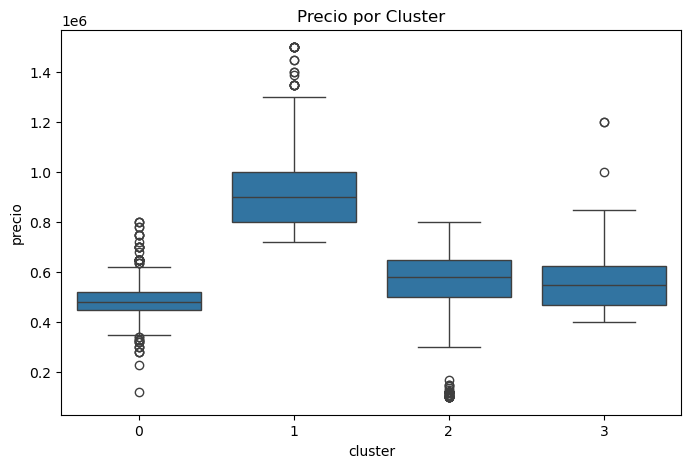

In [8]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(x="cluster", y="precio", data=df)
plt.title("Precio por Cluster")
plt.show()

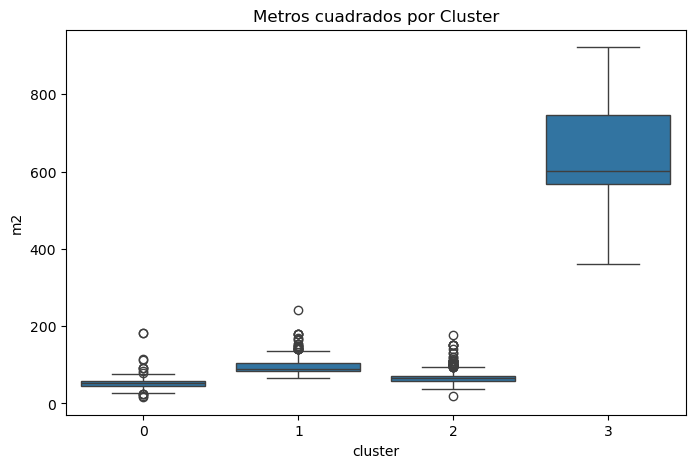

In [9]:
plt.figure(figsize=(8,5))
sns.boxplot(x="cluster", y="m2", data=df)
plt.title("Metros cuadrados por Cluster")
plt.show()

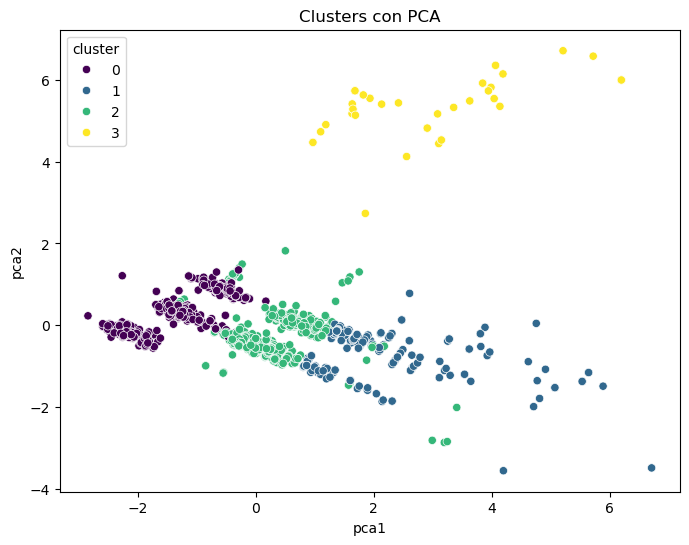

In [10]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
components = pca.fit_transform(X)

df["pca1"] = components[:,0]
df["pca2"] = components[:,1]

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="pca1",
    y="pca2",
    hue="cluster",
    palette="viridis"
)

plt.title("Clusters con PCA")
plt.show()

In [11]:
df.groupby("cluster")[
    ["precio","m2","dormitorios","banos"]
].mean().round(2)

,precio,m2,dormitorios,banos
cluster,,,,
0,485211.06,51.72,2.07,1.00
1,957062.50,98.34,2.84,2.17
2,562052.60,66.69,2.33,2.03
3,588461.54,647.90,3.00,1.59


In [12]:
tabla_clusters = df.groupby("cluster")[
    ["precio","m2","dormitorios","banos"]
].mean().round(2)

print(tabla_clusters)

            precio      m2  dormitorios  banos
cluster                                       
0        485211.06   51.72         2.07   1.00
1        957062.50   98.34         2.84   2.17
2        562052.60   66.69         2.33   2.03
3        588461.54  647.90         3.00   1.59


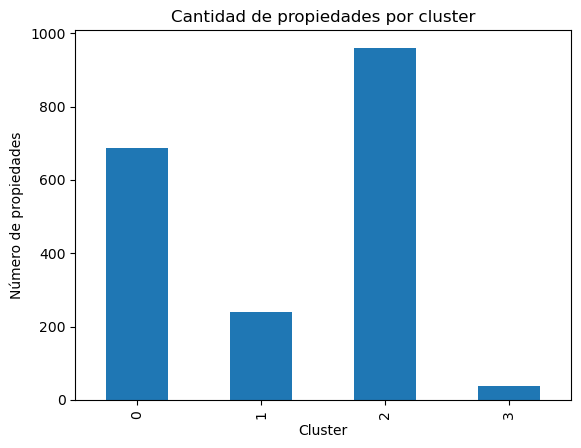

In [13]:
import matplotlib.pyplot as plt

df["cluster"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Cantidad de propiedades por cluster")
plt.xlabel("Cluster")
plt.ylabel("Número de propiedades")

plt.show()

In [14]:
premium = df[df["cluster"] == 1]

premium.sort_values(
    by="precio",
    ascending=True
)[
    ["precio","m2","dormitorios","banos"]
].head(10)

,precio,m2,dormitorios,banos
878,720000,80,3,2
1372,720000,102,3,2
40,720000,80,3,2
588,720000,98,3,2
1762,720000,80,3,2
388,750000,100,3,2
1369,750000,80,3,2
1176,750000,94,3,2
1055,750000,104,3,2
1485,750000,84,3,2


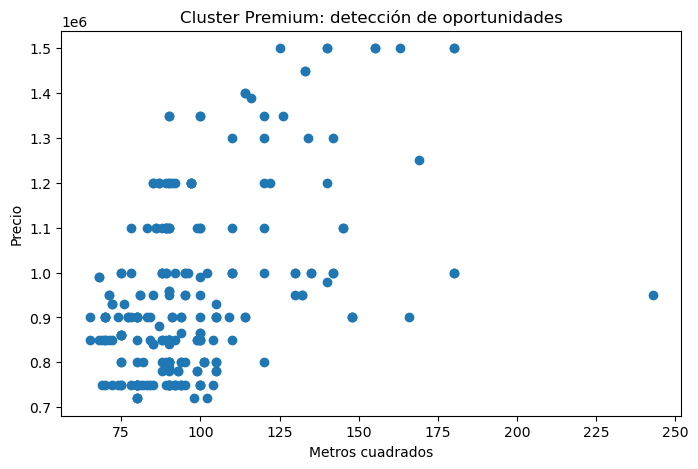

In [15]:
import matplotlib.pyplot as plt

premium = df[df["cluster"] == 1]

plt.figure(figsize=(8,5))

plt.scatter(
    premium["m2"],
    premium["precio"]
)

plt.xlabel("Metros cuadrados")
plt.ylabel("Precio")
plt.title("Cluster Premium: detección de oportunidades")

plt.show()

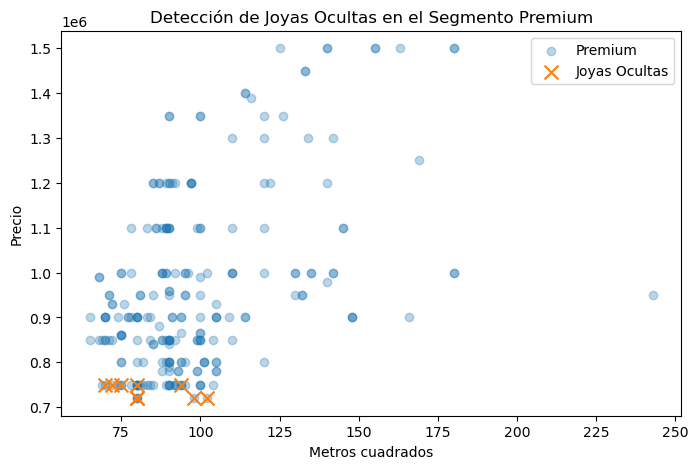

In [16]:
premium = df[df["cluster"] == 1]

joyas = premium.nsmallest(10, "precio")

plt.figure(figsize=(8,5))

plt.scatter(
    premium["m2"],
    premium["precio"],
    alpha=0.3,
    label="Premium"
)

plt.scatter(
    joyas["m2"],
    joyas["precio"],
    marker="x",
    s=100,
    label="Joyas Ocultas"
)

plt.xlabel("Metros cuadrados")
plt.ylabel("Precio")
plt.title("Detección de Joyas Ocultas en el Segmento Premium")

plt.legend()

plt.show()